# Causal Analysis: AI Exposure, Wages, and Unemployment

This notebook studies whether workers in more AI-exposed industries experienced different post-GenAI changes in unemployment and wage income, and whether those effects differ between early-career and older workers.

## Research Question

Main question: did workers in more AI-exposed industries experience different post-GenAI changes in wages and unemployment?

Heterogeneity question: were early-career workers affected differently from older workers?

Because `AIIE` is a time-invariant industry-level exposure measure, the causal variation in this notebook comes from the interaction of industry AI exposure with the post-GenAI period.

## Identification Strategy

We use a repeated-cross-section difference-in-differences design built from CPS ASEC March samples merged to industry-level `AIIE`.

The treatment is not `AIIE` by itself. Instead, treatment intensity is:

- `Post_t x AIIE_j`

where `t` indexes year and `j` indexes industry.

Interpretation: after the broad arrival of generative AI tools, did outcomes change more in industries with higher AI exposure than in industries with lower AI exposure?

Parallel Trends Assumption: without the GenAI shock, outcomes in higher- and lower-exposure industries would have evolved similarly over time.

## Setup and Imports

In [19]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

In [20]:
DATA_PATH = Path('../data/data_with_aiie.csv')
data = pd.read_csv(DATA_PATH)

print(f'Loaded {len(data):,} rows from {DATA_PATH}')
data.head()

Loaded 1,528,045 rows from ../data/data_with_aiie.csv


,YEAR,SERIAL,MONTH,CPSID,ASECFLAG,ASECWTH,PERNUM,CPSIDP,CPSIDV,ASECWT,AGE,EMPSTAT,LABFORCE,OCC,IND,EDUC,INCWAGE,IND_2022,industry_desc,AIIE
0,2016,2,3,20141202933700,1,"1,132.0500",1,20141202933701,201412029337011,"1,132.0500",79,36,1,0,0,30,0,0,NaN,NaN
1,2016,7,3,20151202935900,1,"1,077.5400",1,20151202935901,201512029359011,"1,077.5400",60,32,1,0,0,50,0,0,NaN,NaN
2,2016,7,3,20151202935900,1,"1,077.5400",2,20151202935902,201512029359021,"1,077.5400",59,32,1,0,0,81,0,0,NaN,NaN
3,2016,8,3,20160202937400,1,"1,151.4900",1,20160202937401,201602029374011,"1,151.4900",69,36,1,0,0,81,0,0,NaN,NaN
4,2016,9,3,20160102910900,1,705.0000,1,20160102910901,201601029109011,705.0000,24,21,2,9140,6190,73,6000,6190,Taxi and limousine service,1.3699


In [21]:
data['YEAR'].value_counts()

YEAR
2017    192456
2016    191769
2019    186601
2018    186490
2020    163469
2022    158346
2023    151552
2024    149784
2025    147578
Name: count, dtype: int64

## Timing Differs by Outcome

The CPS ASEC interviews occur in March of each survey year. That timing matters for the two outcomes in this notebook.

- Unemployment is measured close to the survey date, so we can use `2023-2025` as a reasonable post period.
- `INCWAGE` is prior-year annual wage income, so March 2023 mostly reflects 2022 earnings thus likely pre-dates widespread GenAI use.

For that reason we define:

- `post_unemp = 1` for `YEAR >= 2023`
- `post_wage = 1` for `YEAR >= 2024`

and treats 2023 as a transition year for the wage analysis.

## Define Our Sample

We want to restrict our analyses to prime-age workers, to avoid mixing in people in retirement, school. We also only want individuals in the labor force and that have positive income. 

Generally,
- ages `25-64`
- non-missing `AIIE`

Outcome-specific samples:

- Unemployment sample: in the labor force
- Wage sample: employed with positive `INCWAGE`



## Defining Variables ##
- `AIIE`: continuous industry-level AI exposure measure
- `post_unemp`: indicator for `YEAR >= 2023`
- `post_wage`: indicator for `YEAR >= 2024`
- `unemployed`: indicator for unemployed workers in the labor force
- `log_wage`: `log(INCWAGE)` for workers with positive wage income
- `early_career`: ages `25-34`
- `older_worker`: ages `50-64`


We define the following variables for plotting purposes:
- `high_exposure_group`: top quartile of `AIIE` for plots only
- `low_exposure_group`: bottom quartile of `AIIE` for plots only

In [30]:
df = data.copy()


# restrict age to working age population 
df = df[df['AGE'].between(25, 64)].copy()

df = df[df['AIIE'].notna()].copy()

# use employment status coding from CPS/IPUMS convention
df['employed'] = df['EMPSTAT'].isin([10, 12]).astype(int)
df['unemployed'] = df['EMPSTAT'].isin([20, 21,  22]).astype(int)
df['in_labor_force'] = (df['LABFORCE'] == 2).astype(int)

# create indicators for post AIIE period, 2023 for unemployment and 2024 for wage (to reflect timing offset in CPS)
df['post_unemployment'] = (df['YEAR'] >= 2023).astype(int)
df['post_wage'] = (df['YEAR'] >= 2024).astype(int)

# age groups
df['early_career'] = df['AGE'].between(25, 34).astype(int)
df['older_worker'] = df['AGE'].between(50, 64).astype(int)

# wage outcome 
df['positive_wage'] = (df['INCWAGE'] > 0).astype(int)
df['log_wage'] = np.where(df['INCWAGE'] > 0, np.log(df['INCWAGE']), np.nan)

/Users/aeshagandhi/Downloads/MIDS-Sp26/UDS/UDS-Project/.venv/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [31]:
# creative exposure groups for plots  
q1 = df['AIIE'].quantile(0.25)
q3 = df['AIIE'].quantile(0.75)
df['exposure_group'] = np.select(
    [df['AIIE'] <= q1, df['AIIE'] >= q3],
    ['Low exposure', 'High exposure'],
    default='Middle exposure',
)

# analysis samples
unemp_sample = df[df['in_labor_force'] == 1].copy()
wage_sample = df[(df['employed'] == 1) & (df['positive_wage'] == 1)].copy()
wage_did_sample = wage_sample[wage_sample['YEAR'] != 2023].copy()

print('Working-age rows with non-missing AIIE:', f"{len(df):,}")
print('Unemployment sample:', f"{len(unemp_sample):,}")
print('Wage sample:', f"{len(wage_sample):,}")
print('Main wage DiD sample (excluding transition year 2023):', f"{len(wage_did_sample):,}")


Working-age rows with non-missing AIIE: 491,817
Unemployment sample: 488,575
Wage sample: 432,830
Main wage DiD sample (excluding transition year 2023): 387,360


### Helper Functions ###


In [32]:
def weighted_mean(series, weights):
    mask = series.notna() & weights.notna()
    if mask.sum() == 0:
        return np.nan
    return np.average(series[mask], weights=weights[mask])


def summarize_sample(frame, outcome_cols):
    rows = []
    for col in outcome_cols:
        rows.append(
            {
                'variable': col,
                'mean': frame[col].mean(),
                'std': frame[col].std(),
                'min': frame[col].min(),
                'max': frame[col].max(),
                'missing': frame[col].isna().sum(),
            }
        )
    return pd.DataFrame(rows)


def weighted_year_group_mean(frame, value_col, weight_col='ASECWT'):
    out = (
        frame.groupby(['YEAR', 'exposure_group'], observed=True)
        .apply(lambda g: weighted_mean(g[value_col], g[weight_col]))
        .reset_index(name=value_col)
    )
    return out[out['exposure_group'].isin(['Low exposure', 'High exposure'])].copy()


def plot_trends(frame, value_col, title, ylabel):
    plot_df = weighted_year_group_mean(frame, value_col)
    fig, ax = plt.subplots(figsize=(9, 5))
    for group, group_df in plot_df.groupby('exposure_group'):
        ax.plot(group_df['YEAR'], group_df[value_col], marker='o', label=group)
    ax.axvline(2023, color='black', linestyle='--', alpha=0.7, label='2023 unemployment post')
    ax.axvline(2024, color='gray', linestyle=':', alpha=0.9, label='2024 wage post')
    ax.set_title(title)
    ax.set_xlabel('Survey year')
    ax.set_ylabel(ylabel)
    ax.legend()
    plt.show()


def run_wls(formula, frame, cluster_col='IND_2022', weight_col='ASECWT'):
    model = smf.wls(formula=formula, data=frame, weights=frame[weight_col])
    return model.fit(cov_type='cluster', cov_kwds={'groups': frame[cluster_col]})


def coef_table(result, keep=None):
    table = pd.DataFrame(
        {
            'coef': result.params,
            'std_err': result.bse,
            'p_value': result.pvalues,
        }
    )
    if keep is not None:
        mask = table.index.to_series().str.contains(keep, regex=True)
        table = table[mask]
    return table


## Descriptive Statistics ##
check sample sizes, exposure coverage, and outcome patterns

In [33]:
coverage_table = pd.DataFrame(
    {
        'sample': ['Working-age analysis frame', 'Unemployment sample', 'Wage sample', 'Main wage DiD sample'],
        'n_rows': [len(df), len(unemp_sample), len(wage_sample), len(wage_did_sample)],
    }
)
coverage_table

,sample,n_rows
0,Working-age analysis frame,491817
1,Unemployment sample,488575
2,Wage sample,432830
3,Main wage DiD sample,387360


In [34]:
display(summarize_sample(unemp_sample, ['AIIE', 'unemployed', 'AGE']))
display(summarize_sample(wage_sample, ['AIIE', 'INCWAGE', 'log_wage', 'AGE']))

,variable,mean,std,min,max,missing
0,AIIE,0.1039,1.1639,-1.9986,2.2156,0
1,unemployed,0.0370,0.1888,0.0000,1.0000,0
2,AGE,43.1945,10.7839,25.0000,64.0000,0


,variable,mean,std,min,max,missing
0,AIIE,0.1621,1.1583,-1.9986,2.2156,0
1,INCWAGE,"67,522.2445","81,706.5488",2.0000,"2,099,999.0000",0
2,log_wage,10.7537,0.8995,0.6931,14.5574,0
3,AGE,43.1004,10.7655,25.0000,64.0000,0


In [35]:
display(unemp_sample.groupby('YEAR').size().rename('unemployment_sample_n').to_frame())
display(wage_did_sample.groupby('YEAR').size().rename('wage_sample_n').to_frame())

,unemployment_sample_n
YEAR,
2016,57638
2017,58270
2018,56375
2019,56929
2020,54754
2022,52850
2023,50876
2024,50831
2025,50052


,wage_sample_n
YEAR,
2016,50320
2017,51074
2018,49726
2019,50588
2020,48316
2022,47023
2024,45466
2025,44847


In [36]:
unemp_pre_post = (
    unemp_sample[unemp_sample['exposure_group'].isin(['Low exposure', 'High exposure'])]
    .groupby(['post_unemployment', 'exposure_group'], observed=True)
    .apply(lambda g: weighted_mean(g['unemployed'], g['ASECWT']))
    .reset_index(name='weighted_unemployment_rate')
)

wage_pre_post = (
    wage_did_sample[wage_did_sample['exposure_group'].isin(['Low exposure', 'High exposure'])]
    .groupby(['post_wage', 'exposure_group'], observed=True)
    .apply(lambda g: weighted_mean(g['log_wage'], g['ASECWT']))
    .reset_index(name='weighted_mean_log_wage')
)

display(unemp_pre_post)
display(wage_pre_post)

,post_unemployment,exposure_group,weighted_unemployment_rate
0,0,High exposure,0.0237
1,0,Low exposure,0.0593
2,1,High exposure,0.0217
3,1,Low exposure,0.0500


,post_wage,exposure_group,weighted_mean_log_wage
0,0,High exposure,10.9063
1,0,Low exposure,10.5270
2,1,High exposure,11.1769
3,1,Low exposure,10.7747


### Outcome Trends by AI Exposure ###
Visualize high and low exposure industries

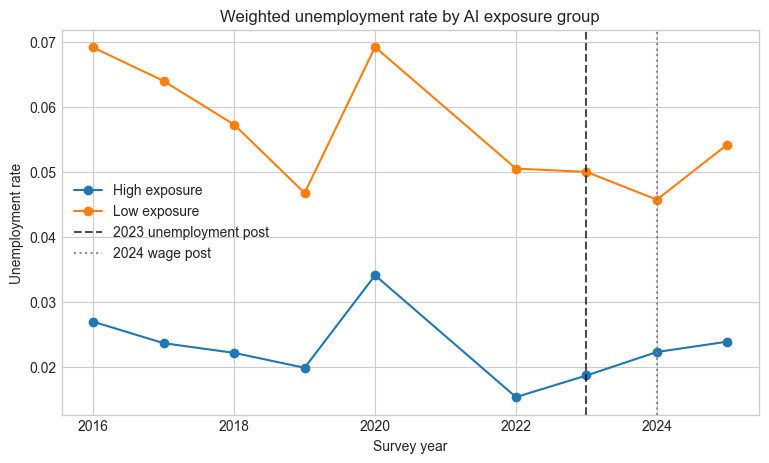

In [37]:
plot_trends(
    unemp_sample,
    value_col='unemployed',
    title='Weighted unemployment rate by AI exposure group',
    ylabel='Unemployment rate',
)

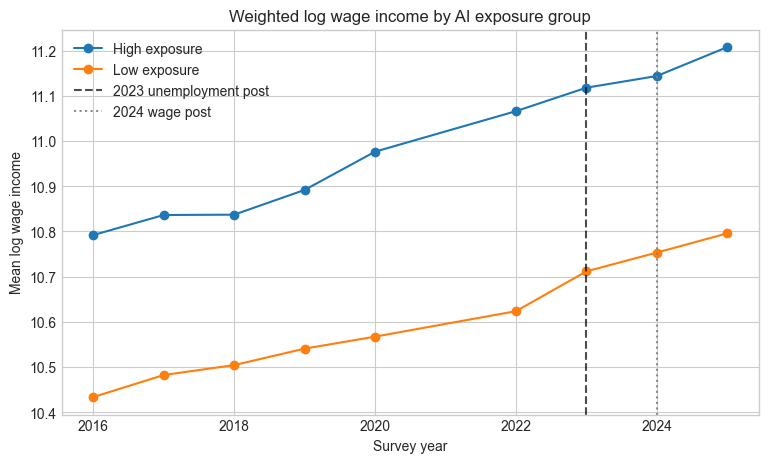

In [38]:
plot_trends(
    wage_sample,
    value_col='log_wage',
    title='Weighted log wage income by AI exposure group',
    ylabel='Mean log wage income',
)

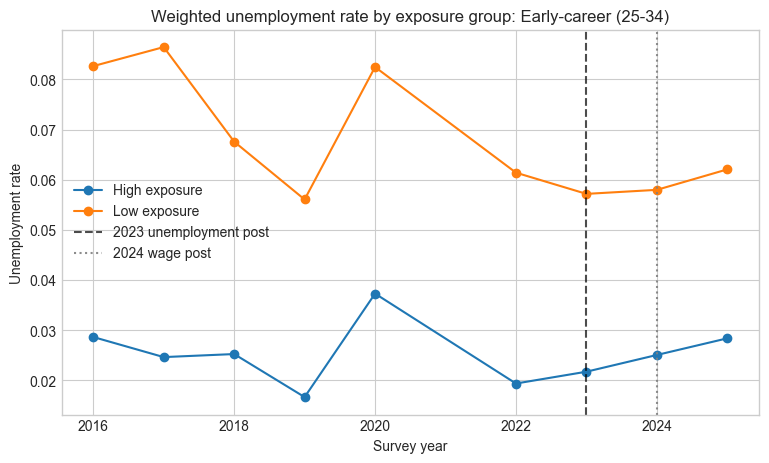

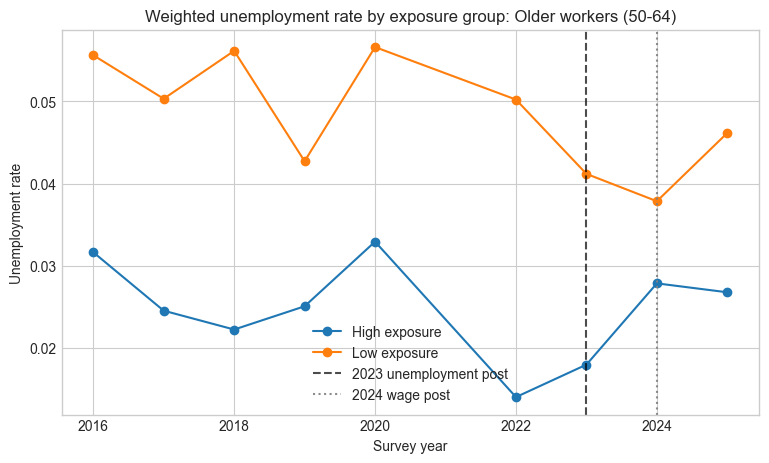

In [39]:
for label, subset in {
    'Early-career (25-34)': unemp_sample[unemp_sample['early_career'] == 1],
    'Older workers (50-64)': unemp_sample[unemp_sample['older_worker'] == 1],
}.items():
    plot_trends(
        subset,
        value_col='unemployed',
        title=f'Weighted unemployment rate by exposure group: {label}',
        ylabel='Unemployment rate',
    )